# Introduction to Machine Learning

In [2]:
import sklearn

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [6]:
housing = pd.read_csv("/Users/sanasalim/Downloads/Linkific/Day 7/house_price_regression_dataset.csv")

### Exploring Data

In [8]:
housing.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [9]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [10]:
housing.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


<Axes: >

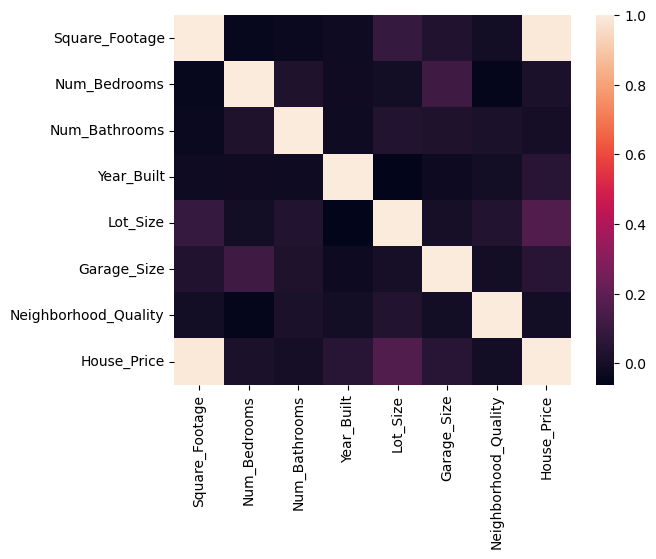

In [15]:
sns.heatmap(housing.corr())
# price has high correlation with square footage so strongest predictor

### Handle Missing Values

In [12]:
housing.isnull().sum()
# use fillna to replace with median if missing values present

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

In [61]:
y = housing["House_Price"]
features = ["Square_Footage","Num_Bedrooms","Num_Bathrooms","Lot_Size","Garage_Size","Neighborhood_Quality"]
X = housing[features]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42, shuffle=True)
model = LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [79]:
compare = pd.DataFrame({'Actual($)':y_test.values.astype(int),'Predicted($)': y_pred.astype(int)})

In [30]:
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("RMSE:$",rmse.round(0))
print("R2:",r2)
print("MAE:$",mae.round(0))

RMSE:$ 22031.0
R2: 0.9924702735621432
MAE:$ 18422.0


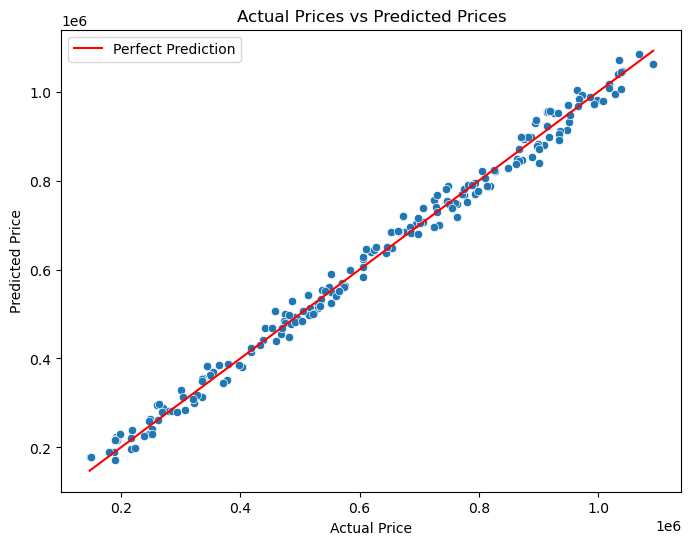

In [52]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred)
# y=x line to represent a perfect prediction
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],label='Perfect Prediction',color="red")
plt.title('Actual Values vs Predicted Values')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.legend()

In [53]:
compare[:20]

,Actual ($),Predicted ($)
0,901000,839882
1,494537,490387
2,949404,970971
3,1040389,1046707
4,794010,770184
5,724033,756489
6,998439,982233
7,909713,879325
8,792681,795467
9,947490,914083


In [73]:
joblib.dump(model,"House_Price.pkl")
loaded = joblib.load('House_Price.pkl')
loaded.predict(X_test[:1])[0]

839882.7374118854

In [75]:
# realised i forgot the Year_Built column earlier
new_house = pd.DataFrame([{'Square_Footage':2000,'Num_Bedrooms':3,'Num_Bathrooms':2,'Lot_Size':0.25,'Garage_Size':2,'Neighborhood_Quality':7}])
price = loaded.predict(new_house)[0]
print(price)

425156.2314562696


In [78]:
import os
print(os.getcwd())

/Users/sanasalim/Downloads/Linkific/Day 5
